In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import pathlib
from pyometiff import OMETIFFReader
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
from sklearn.cluster import KMeans

from sklearn.ensemble import IsolationForest
from sklearn import linear_model

img_fpath = pathlib.Path("./test.tif")
reader = OMETIFFReader(fpath=img_fpath)
img_array, metadata, xml_metadata = reader.read()
img_array.shape

key not found 'NoneType' object has no attribute 'iter'
Key not found: 'NoneType' object has no attribute 'iter'


(1000, 520, 696)

In [67]:
select = 6
th = 30

if select == 0:
    # 1. Rango
    var_im = np.max(img_array, axis=0) - np.min(img_array, axis=0)
    th = 100

if select == 1:
    # 2. Varianza
    var_im = np.var(img_array, axis=0)  # Poblacional
    th = 200

if select == 2:
    # 2. Varianza
    var_im = np.var(img_array, axis=0, ddof=1)  # Muestral
    th = 200

if select == 3:
    # 3. Desviación estándar
    th = 12
    var_im = np.std(img_array, axis=0)  # Poblacional

if select == 4:
    # 3. Desviación estándar
    th = 12
    var_im = np.std(img_array, axis=0, ddof=1)  # Muestral

if select == 5:
    # 4. Coeficiente de variación
    th = 5
    var_im = np.std(img_array, axis=0, ddof=1)  # Muestral
    media = np.mean(img_array, axis=0)
    var_im = (var_im / media) * 100

if select == 6:
    th = 20
    # 5. Rango intercuartílico (IQR)
    q1 = np.percentile(img_array, 25, axis=0)
    q3 = np.percentile(img_array, 75, axis=0)
    var_im = q3 - q1

In [68]:
from skimage.filters import unsharp_mask
result_1 = unsharp_mask(var_im, radius=20, amount=1)
kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
image = cv.filter2D(var_im, -1, kernel)

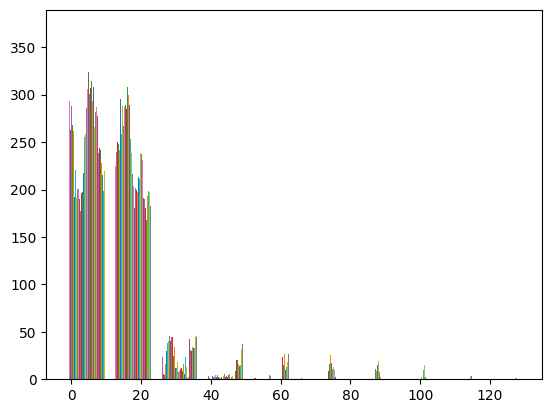

In [69]:
histogram = plt.hist(image)

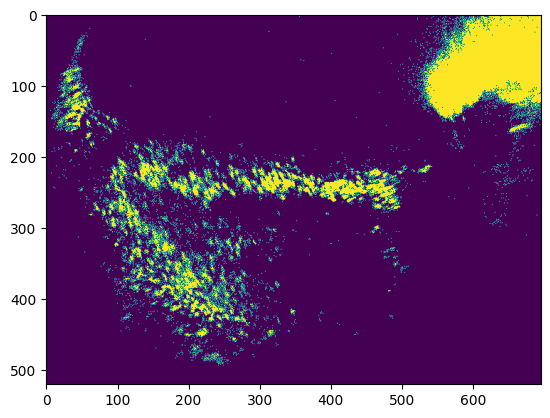

In [70]:
deconvolved_RL2 = np.reshape(image, (image.shape[0] * image.shape[1]))
res_labels = [int(deconvolved_RL2[i] > th) for i in range(len(deconvolved_RL2))]
res_labels = np.reshape(res_labels, (image.shape[0], image.shape[1]))
plt.imshow(res_labels)
plt.show()

In [33]:
def candidate_neighbors(node):
    return [(node[0] + 1, node[1]), (node[0], node[1] + 1), (node[0] + 1, node[1] + 1),
           (node[0] - 1, node[1]), (node[0], node[1] - 1), (node[0] - 1, node[1] - 1),
           (node[0] + 1, node[1] - 1), (node[0] - 1, node[1] + 1)]

def neighboring_groups(nodes):
    remain = set(nodes)
    while len(remain) > 0:
        visit = [remain.pop()]
        group = []
        while len(visit) > 0:
            node = visit.pop()
            group.append(node)
            for nb in candidate_neighbors(node):
                if nb in remain:
                    remain.remove(nb)
                    visit.append(nb)
        yield group

# nodes = [1, 22, 5, 20, 3, 4, 21, 2]
# print(list(neighboring_groups(nodes)))

In [34]:
pixels = []
for i in range(res_labels.shape[0]):
    for j in range(res_labels.shape[1]):
        if res_labels[i][j] == True:
            pixels.append((i, j))

In [35]:
res_clusters = list(neighboring_groups(pixels))
len(res_clusters)

1663

In [36]:
len(res_clusters[0])

2790

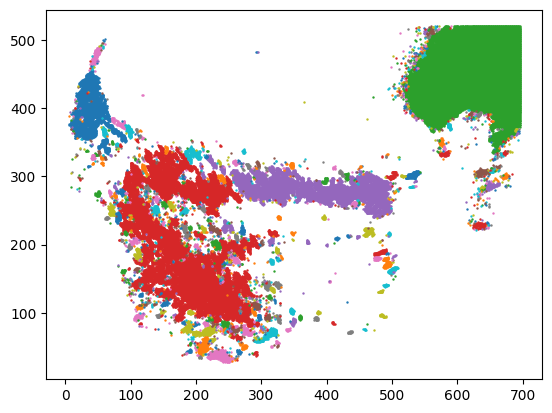

In [37]:
#plotting the results:
fig = plt.figure()
for cl in res_clusters:
    plt.scatter(np.array(cl)[:, 1], np.array(var_im).shape[0] - np.array(cl)[:, 0], marker='o', s=(72./fig.dpi)**2)
plt.show()

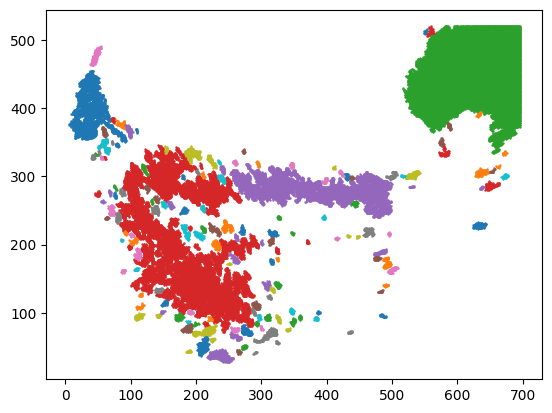

In [38]:
#plotting the results:
min_size = 10
max_cluster = 0
sel_cluster = 0
fig = plt.figure()
clusters_min_size = []
for cl in res_clusters:
    if len(cl) >= min_size:
        clusters_min_size.append(cl)
        plt.scatter(np.array(cl)[:, 1], np.array(var_im).shape[0] - np.array(cl)[:, 0], marker='o', s=(72./fig.dpi)**2)
plt.show()

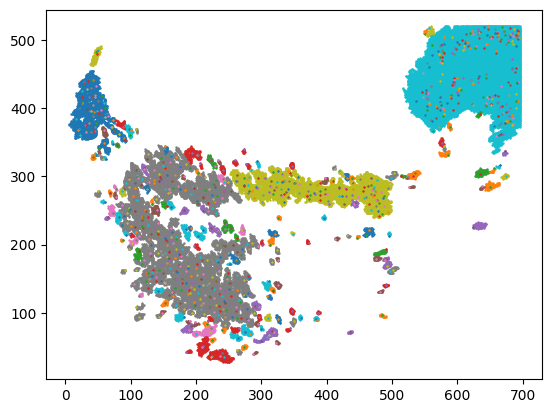

In [39]:
max_size = 0

for cl in clusters_min_size:
    plt.scatter(np.array(cl)[:, 1], np.array(var_im).shape[0] - np.array(cl)[:, 0], marker='o', s=(72./fig.dpi)**2)

    z = []
    x = []
    y = []
    for i in range(len(cl)):
        z.append(var_im[cl[i]])
        x.append(cl[i][0])
        y.append(cl[i][1])
    z = np.array(z)
    y = np.array(y)
    x = np.array(x)

    clf = linear_model.SGDOneClassSVM(random_state=42, nu=0.131).fit(z.reshape(-1, 1))
    y_pred = clf.predict(z.reshape(-1, 1))
    y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]
    min_x = min(x)
    max_x = max(x)
    min_y = min(y)
    max_y = max(y)
    min_x, max_x, min_y, max_y
    Z = np.zeros((max_x - min_x + 1, max_y - min_y + 1))
    for i in range(len(z)):
        Z[x[i] - min_x, y[i] - min_y] = z[i]
    # Calcular derivadas parciales numéricas
    dz_dx = np.gradient(Z, axis=1)  # Derivada parcial respecto a x
    dz_dy = np.gradient(Z, axis=0)  # Derivada parcial respecto a y

    peaks = []
    for i in range(1, Z.shape[0] - 1):       # Ignorar bordes
        for j in range(1, Z.shape[1] - 1):   # Ignorar bordes
            # Verificar cambio de signo en las derivadas
            if dz_dx[i, j - 1] > 0 and dz_dx[i, j] <= 0 and dz_dy[i - 1, j] > 0 and dz_dy[i, j] <= 0:
                if Z[i - 1, j] == 0 or Z[i + 1, j] == 0 or Z[i, j - 1] == 0 or Z[i, j + 1] == 0:
                    continue
                # Verificar si es un máximo local comparándolo con sus vecinos
                peaks.append((i + min_x, j + min_y, Z[i][j]))

    if len(peaks) == 0:
        i = np.argmin(z)
        plt.scatter(np.array(y)[i], np.array(var_im).shape[0] - np.array(x)[i], marker='*', s=(72./fig.dpi)**2)

    for i in range(len(peaks)):
        plt.scatter(np.array(peaks)[i][1], np.array(var_im).shape[0] - np.array(peaks)[i][0], marker='*', s=(72./fig.dpi)**2)

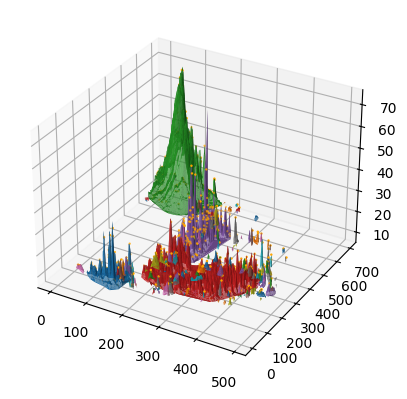

In [40]:
max_size = 0
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
show_peaks = True
all_peaks = []

for cl in clusters_min_size:

    z = []
    x = []
    y = []
    for i in range(len(cl)):
        z.append(var_im[cl[i]])
        x.append(cl[i][0])
        y.append(cl[i][1])
    z = np.array(z)
    y = np.array(y)
    x = np.array(x)

    clf = linear_model.SGDOneClassSVM(random_state=42, nu=0.131).fit(z.reshape(-1, 1))
    y_pred = clf.predict(z.reshape(-1, 1))
    y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]
    min_x = min(x)
    max_x = max(x)
    min_y = min(y)
    max_y = max(y)
    min_x, max_x, min_y, max_y
    Z = np.zeros((max_x - min_x + 1, max_y - min_y + 1))
    for i in range(len(z)):
        Z[x[i] - min_x, y[i] - min_y] = z[i]
    # Calcular derivadas parciales numéricas
    dz_dx = np.gradient(Z, axis=1)  # Derivada parcial respecto a x
    dz_dy = np.gradient(Z, axis=0)  # Derivada parcial respecto a y

    peaks = []
    for i in range(1, Z.shape[0] - 1):       # Ignorar bordes
        for j in range(1, Z.shape[1] - 1):   # Ignorar bordes
            # Verificar cambio de signo en las derivadas
            if dz_dx[i, j - 1] > 0 and dz_dx[i, j] <= 0 and dz_dy[i - 1, j] > 0 and dz_dy[i, j] <= 0:
                if Z[i - 1, j] == 0 or Z[i + 1, j] == 0 or Z[i, j - 1] == 0 or Z[i, j + 1] == 0:
                    continue
                # Verificar si es un máximo local comparándolo con sus vecinos
                peaks.append((i + min_x, j + min_y, Z[i][j]))
                all_peaks.append((i + min_x, j + min_y, Z[i][j]))

    ax.plot_trisurf(x, y, z, linewidth=0.2, antialiased=True)
    if show_peaks:
        x_p = []
        y_p = []
        z_p = []
        for i in range(len(peaks)):
            x_p.append(peaks[i][0])
            y_p.append(peaks[i][1])
            z_p.append(peaks[i][2])
        ax.scatter(x_p, y_p, z_p, color='orange', s=(72./fig.dpi)**2)
plt.show()

In [41]:
num_peak = len(all_peaks) - 1
sel_cluster = all_peaks[num_peak]
sel_cluster

(420, 148, 12.505352414066547)

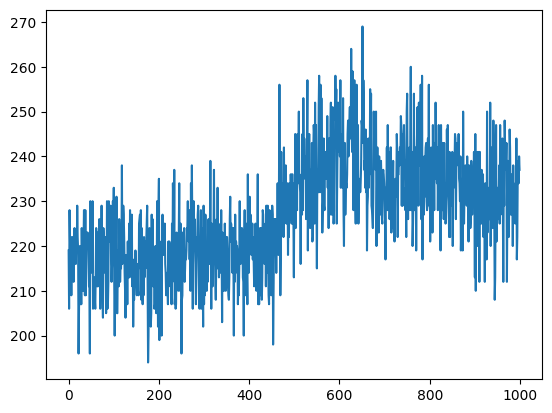

In [42]:
sel_data = img_array[:, sel_cluster[0], sel_cluster[1]]
plt.plot(np.array(range(len(sel_data))).reshape(-1, 1), sel_data)
plt.show()